# NBA Text-to-SQL Results Plots

This notebook loads aggregated CSV outputs from `eval/` and generates publishable figures for the final write-up and presentation.


In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Robust path resolution whether notebook runs from repo root or notebooks/
if Path("eval").exists():
    EVAL_DIR = Path("eval")
elif Path("../eval").exists():
    EVAL_DIR = Path("../eval")
else:
    raise FileNotFoundError("Cannot find eval/ directory")

results = pd.read_csv(EVAL_DIR / "results_summary.csv")
fewshot = pd.read_csv(EVAL_DIR / "fewshot_curve.csv")
rag = pd.read_csv(EVAL_DIR / "rag_ablation.csv")

results.head()

,file,run,model,method,mode,split,n_examples,n_train,exec_acc,exec_ci_low,exec_ci_high,exact_acc,exact_ci_low,exact_ci_high
0,baseline_nba_fewshot_t5-base_test.json,baseline_nba_fewshot_t5-base_test,t5-base,baseline,other,test,50,NaN,0.00,0.0,0.00,0.00,0.0,0.00
1,baseline_nba_zeroshot_t5-base_test.json,baseline_nba_zeroshot_t5-base_test,t5-base,baseline,other,test,50,NaN,0.00,0.0,0.00,0.00,0.0,0.00
2,full_t5-base_nba_oracle_test.json,full_t5-base_nba_oracle_test,t5-base,full,oracle,test,50,0,0.04,0.0,0.10,0.00,0.0,0.00
3,lora_codet5p-220m_r16_bs4_r16_lr0.0001_s42_nba...,lora_codet5p-220m_r16_bs4_r16_lr0.0001_s42_nba...,codet5p-220m,lora,oracle,test,10,0,0.00,0.0,0.00,0.00,0.0,0.00
4,lora_codet5p-220m_r16_nba_n10_s42_nba_oracle_t...,lora_codet5p-220m_r16_nba_n10_s42_nba_oracle_test,codet5p-220m,lora,oracle,test,50,10,0.06,0.0,0.14,0.02,0.0,0.06


## Figure 1. Main leaderboard on NBA test (Execution Accuracy)

Use this bar chart in the Results section to compare methods/runs on the same held-out split.

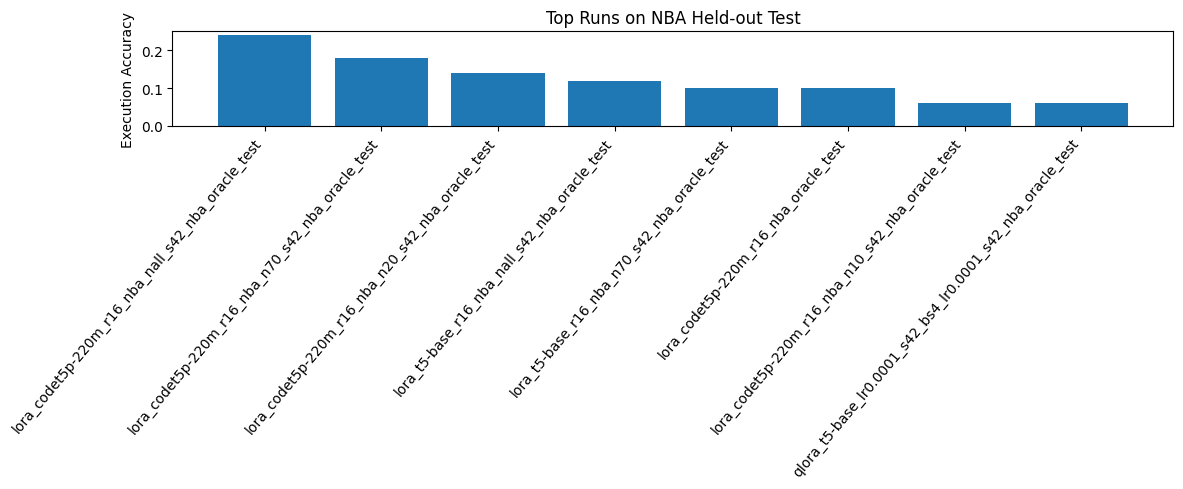

In [22]:
plot_df = results.copy()
plot_df = plot_df.sort_values("exec_acc", ascending=False).head(8)

plt.figure(figsize=(12, 5))
plt.bar(plot_df["run"], plot_df["exec_acc"])
plt.xticks(rotation=50, ha="right")
plt.ylabel("Execution Accuracy")
plt.title("Top Runs on NBA Held-out Test")
plt.ylim(0, 0.6)
plt.tight_layout()
plt.show()

## Figure 2. Few-shot adaptation curve (Spider -> NBA)

This plot shows how much NBA supervision is needed to close the transfer gap.

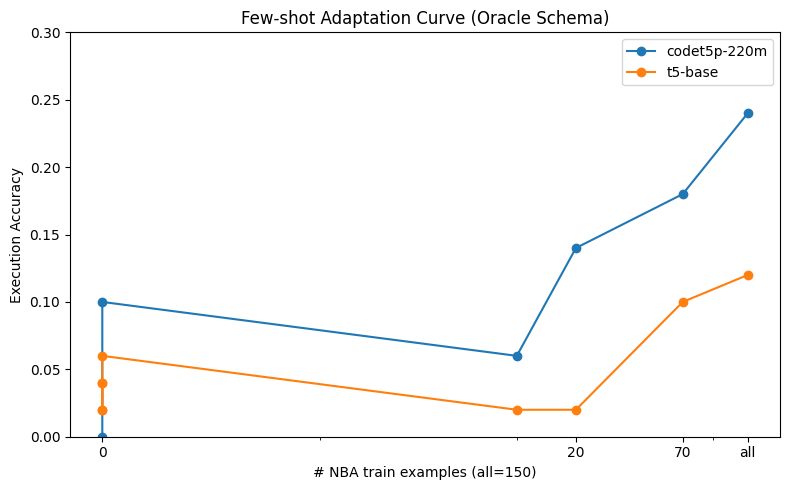

In [23]:
curve = fewshot.copy()
curve["n_train_num"] = curve["n_train"].replace({"all": 150}).astype(int)

plt.figure(figsize=(8, 5))
for model, g in curve.groupby("model"):
    g = g.sort_values("n_train_num")
    plt.plot(g["n_train_num"], g["exec_acc"], marker="o", label=model)

plt.xlabel("# NBA train examples (all=150)")
plt.ylabel("Execution Accuracy")
plt.title("Few-shot Adaptation Curve (Oracle Schema)")
plt.xscale("symlog", linthresh=1)
plt.xticks([0, 20, 70, 150], ["0", "20", "70", "all"])
plt.ylim(0, 0.55)
plt.legend()
plt.tight_layout()
plt.show()

## Figure 3. RAG ablation (top-k)

Compare RAG settings to explain where retrieval hurts or helps.

C:\Users\stanw\AppData\Local\Temp\ipykernel_90844\4227812431.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


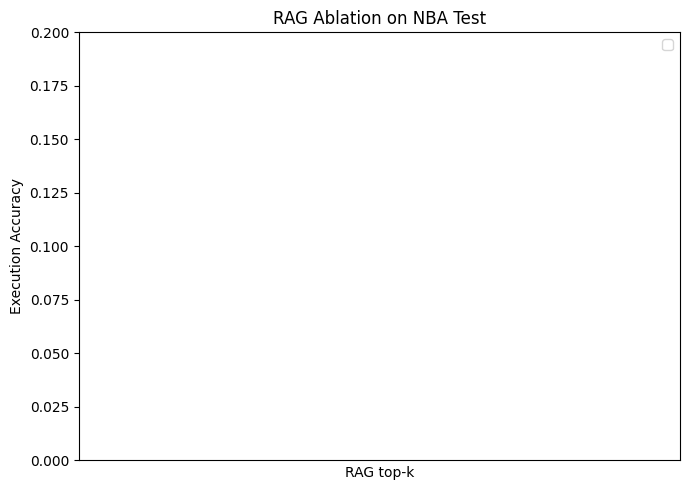

In [24]:
rag_plot = rag.copy()
rag_plot["k"] = rag_plot["file"].str.extract(r"rag_k(\d+)").astype(float)
rag_plot = rag_plot.dropna(subset=["k"]).sort_values(["model", "k"])

plt.figure(figsize=(7, 5))
for model, g in rag_plot.groupby("model"):
    plt.plot(g["k"], g["exec_acc"], marker="o", label=model)

plt.xlabel("RAG top-k")
plt.ylabel("Execution Accuracy")
plt.title("RAG Ablation on NBA Test")
plt.xticks(sorted(rag_plot["k"].unique()))
plt.ylim(0, 0.2)
plt.legend()
plt.tight_layout()
plt.show()

## Export figure-ready tables

Use this cell to print compact tables you can paste into the write-up appendix or speaker notes.

In [25]:
main_cols = ["run", "model", "method", "mode", "exec_acc", "exact_acc"]
results.sort_values("exec_acc", ascending=False)[main_cols].head(12)

,run,model,method,mode,exec_acc,exact_acc
7,lora_codet5p-220m_r16_nba_nall_s42_nba_oracle_...,codet5p-220m,lora,oracle,0.24,0.16
6,lora_codet5p-220m_r16_nba_n70_s42_nba_oracle_test,codet5p-220m,lora,oracle,0.18,0.06
5,lora_codet5p-220m_r16_nba_n20_s42_nba_oracle_test,codet5p-220m,lora,oracle,0.14,0.06
12,lora_t5-base_r16_nba_nall_s42_nba_oracle_test,t5-base,lora,oracle,0.12,0.10
11,lora_t5-base_r16_nba_n70_s42_nba_oracle_test,t5-base,lora,oracle,0.10,0.06
8,lora_codet5p-220m_r16_nba_oracle_test,codet5p-220m,lora,oracle,0.10,0.00
4,lora_codet5p-220m_r16_nba_n10_s42_nba_oracle_test,codet5p-220m,lora,oracle,0.06,0.02
16,qlora_t5-base_lr0.0001_s42_bs4_lr0.0001_s42_nb...,t5-base,qlora,oracle,0.06,0.02
2,full_t5-base_nba_oracle_test,t5-base,full,oracle,0.04,0.00
13,lora_t5-base_r16_nba_oracle_test,t5-base,lora,oracle,0.04,0.02


## Current blockers and limitations

- Some planned outputs are missing because corresponding local checkpoints are not present in this workspace snapshot (`models/` is empty).
- `evaluate.py` and training scripts require CUDA by default; CPU fallback is only for debug and is too slow for full matrix completion.
- Current summary is informative for course deliverables, but not yet multi-seed/statistically rigorous.

## Spider source-domain comparison

This section compares source-domain (Spider) exact match across trained checkpoints.

In [26]:
spider = pd.read_csv(EVAL_DIR / "spider_summary.csv")
spider

,file,run,model,n_examples,exec_acc,exec_ci_low,exec_ci_high,exact_acc,exact_ci_low,exact_ci_high
0,lora_codet5p-220m_r16_bs4_r16_lr0.0001_s42_spi...,lora_codet5p-220m_r16_bs4_r16_lr0.0001_s42_spider,codet5p-220m,200,0.0,0.0,0.0,0.325,0.260,0.390
1,lora_codet5p-220m_r16_spider.json,lora_codet5p-220m_r16_spider,codet5p-220m,200,0.0,0.0,0.0,0.290,0.230,0.355
2,full_t5-base_spider.json,full_t5-base_spider,t5-base,200,0.0,0.0,0.0,0.265,0.205,0.325
3,qlora_t5-base_lr0.0001_s42_bs4_lr0.0001_s42_sp...,qlora_t5-base_lr0.0001_s42_bs4_lr0.0001_s42_sp...,t5-base,200,0.0,0.0,0.0,0.175,0.125,0.230
4,lora_t5-base_r8_spider.json,lora_t5-base_r8_spider,t5-base,200,0.0,0.0,0.0,0.145,0.100,0.195
5,lora_t5-base_r16_spider.json,lora_t5-base_r16_spider,t5-base,200,0.0,0.0,0.0,0.120,0.075,0.165
6,lora_t5-base_r4_spider.json,lora_t5-base_r4_spider,t5-base,200,0.0,0.0,0.0,0.070,0.035,0.105


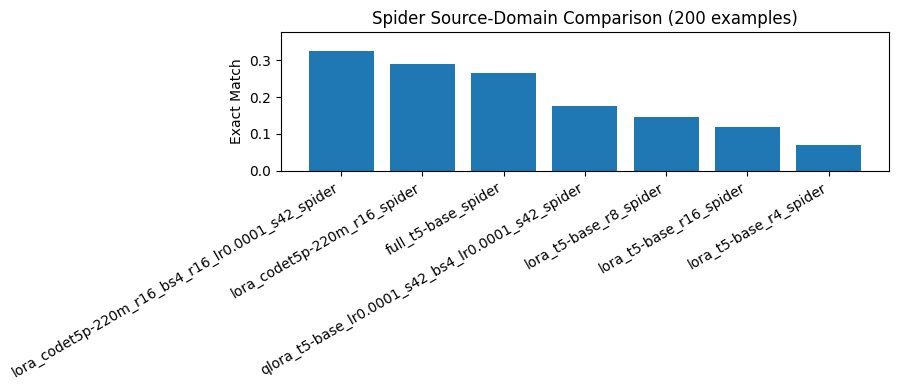

In [27]:
plt.figure(figsize=(9, 4))
plt.bar(spider["run"], spider["exact_acc"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Exact Match")
plt.title("Spider Source-Domain Comparison (200 examples)")
plt.ylim(0, max(0.35, spider["exact_acc"].max() + 0.05))
plt.tight_layout()
plt.show()

## Snapshot refresh (latest)

This section is regenerated from current `eval/*.csv` outputs to track remaining gaps and latest leaderboard state.

C:\Users\stanw\AppData\Local\Temp\ipykernel_90844\1646392881.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


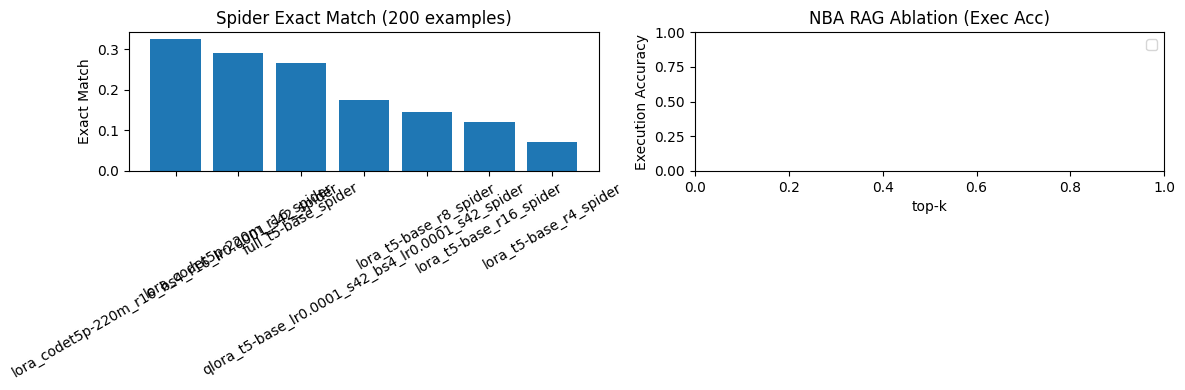

In [28]:
spider_latest = pd.read_csv(EVAL_DIR / "spider_summary.csv")
rag_latest = pd.read_csv(EVAL_DIR / "rag_ablation.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Spider exact-match comparison
axes[0].bar(spider_latest["run"], spider_latest["exact_acc"])
axes[0].set_title("Spider Exact Match (200 examples)")
axes[0].set_ylabel("Exact Match")
axes[0].tick_params(axis="x", rotation=30)

# RAG ablation comparison on NBA test
for model, g in rag_latest.groupby("model"):
    g = g.copy()
    g["k"] = g["file"].str.extract(r"rag_k(\d+)").astype(float)
    g = g.sort_values("k")
    axes[1].plot(g["k"], g["exec_acc"], marker="o", label=model)
axes[1].set_title("NBA RAG Ablation (Exec Acc)")
axes[1].set_xlabel("top-k")
axes[1].set_ylabel("Execution Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()